# Individual performances

This notebook highlights the individual performances of each models on each datasets.

Results are not presented in the paper but can be useful to have some better understanding of some results.

In [3]:
import numpy as np
import pandas as pd

from utils import load_nested_results

all_results = load_nested_results("results")

In [4]:
from sklearn.metrics import average_precision_score

datasets_names = list(all_results.keys())
n_fold = len(all_results[datasets_names[0]]["ground_truth"].keys())

all_res_summary = {}

for dataset in datasets_names:
    results = all_results[dataset]

    all_res = []
    for fold in range(n_fold):
        y_true = results["ground_truth"][fold]

        if len(np.unique(y_true)) == 1:
            continue

        fold_res = []

        for model_name in list(results.keys() - {"ground_truth"}):
            y_scores = results[model_name][fold]["scores"]
            auc = average_precision_score(y_true, y_scores)
            fold_res.append(auc)

        all_res.append(fold_res)
    all_res = np.array(all_res)
    mean_res = np.mean(all_res, axis=0)
    std_res = np.std(all_res, axis=0)

    all_res_summary[dataset.split("_")[1]] = [
        f"{mean_res[i]:.2f} ± {std_res[i]:.2f}" for i in range(len(mean_res))
    ]

In [5]:
df = pd.DataFrame.from_dict(
    all_res_summary,
    orient="index",
    columns=list(results.keys() - {"ground_truth"}),
)
df

,AutoEncoder,CBLOF,ECOD,GMM,OCSVM,COPOD,KNN,LOF,PCA,IForest,DeepSVDD,MCD,HBOS,LODA
annthyroid,0.25 ± 0.03,0.18 ± 0.03,0.29 ± 0.04,0.16 ± 0.02,0.20 ± 0.03,0.18 ± 0.01,0.24 ± 0.02,0.19 ± 0.02,0.21 ± 0.03,0.30 ± 0.04,0.20 ± 0.08,0.52 ± 0.02,0.25 ± 0.02,0.11 ± 0.04
breastw,0.89 ± 0.06,0.88 ± 0.06,0.99 ± 0.01,0.92 ± 0.04,0.93 ± 0.04,0.99 ± 0.01,0.92 ± 0.04,0.33 ± 0.04,0.96 ± 0.02,0.97 ± 0.02,0.91 ± 0.04,0.97 ± 0.02,0.96 ± 0.02,0.98 ± 0.01
glass,0.14 ± 0.07,0.17 ± 0.04,0.10 ± 0.06,0.11 ± 0.05,0.10 ± 0.07,0.11 ± 0.06,0.15 ± 0.04,0.11 ± 0.05,0.09 ± 0.05,0.11 ± 0.05,0.11 ± 0.06,0.12 ± 0.04,0.11 ± 0.05,0.07 ± 0.04
Hepatitis,0.61 ± 0.27,0.57 ± 0.26,0.51 ± 0.19,0.52 ± 0.23,0.57 ± 0.21,0.59 ± 0.23,0.55 ± 0.24,0.52 ± 0.18,0.60 ± 0.27,0.54 ± 0.22,0.49 ± 0.26,0.58 ± 0.18,0.47 ± 0.22,0.37 ± 0.19
Lymphography,0.97 ± 0.07,0.97 ± 0.07,1.00 ± 0.00,0.78 ± 0.27,0.92 ± 0.17,1.00 ± 0.00,0.97 ± 0.07,0.97 ± 0.07,0.97 ± 0.07,1.00 ± 0.00,1.00 ± 0.00,0.74 ± 0.22,1.00 ± 0.00,0.77 ± 0.20
mammography,0.16 ± 0.07,0.16 ± 0.05,0.46 ± 0.06,0.20 ± 0.04,0.21 ± 0.04,0.45 ± 0.06,0.18 ± 0.05,0.10 ± 0.02,0.23 ± 0.04,0.20 ± 0.04,0.21 ± 0.06,0.04 ± 0.01,0.15 ± 0.05,0.22 ± 0.10
PageBlocks,0.51 ± 0.06,0.56 ± 0.06,0.53 ± 0.06,0.56 ± 0.06,0.54 ± 0.06,0.38 ± 0.04,0.54 ± 0.07,0.36 ± 0.03,0.52 ± 0.05,0.47 ± 0.04,0.55 ± 0.11,0.62 ± 0.04,0.32 ± 0.04,0.44 ± 0.11
Pima,0.49 ± 0.05,0.49 ± 0.04,0.48 ± 0.04,0.51 ± 0.03,0.48 ± 0.04,0.52 ± 0.05,0.52 ± 0.04,0.43 ± 0.04,0.50 ± 0.04,0.50 ± 0.05,0.47 ± 0.04,0.50 ± 0.03,0.55 ± 0.06,0.42 ± 0.06
Stamps,0.43 ± 0.15,0.29 ± 0.07,0.51 ± 0.18,0.41 ± 0.12,0.45 ± 0.15,0.65 ± 0.18,0.44 ± 0.15,0.28 ± 0.09,0.52 ± 0.14,0.50 ± 0.15,0.37 ± 0.13,0.40 ± 0.11,0.50 ± 0.08,0.51 ± 0.17
thyroid,0.43 ± 0.13,0.33 ± 0.12,0.55 ± 0.11,0.33 ± 0.09,0.41 ± 0.10,0.24 ± 0.07,0.38 ± 0.11,0.12 ± 0.03,0.43 ± 0.09,0.57 ± 0.14,0.39 ± 0.09,0.73 ± 0.10,0.56 ± 0.10,0.25 ± 0.09


In [6]:
df.to_latex()

'\\begin{tabular}{lllllllllllllll}\n\\toprule\n & AutoEncoder & CBLOF & ECOD & GMM & OCSVM & COPOD & KNN & LOF & PCA & IForest & DeepSVDD & MCD & HBOS & LODA \\\\\n\\midrule\nannthyroid & 0.25 ± 0.03 & 0.18 ± 0.03 & 0.29 ± 0.04 & 0.16 ± 0.02 & 0.20 ± 0.03 & 0.18 ± 0.01 & 0.24 ± 0.02 & 0.19 ± 0.02 & 0.21 ± 0.03 & 0.30 ± 0.04 & 0.20 ± 0.08 & 0.52 ± 0.02 & 0.25 ± 0.02 & 0.11 ± 0.04 \\\\\nbreastw & 0.89 ± 0.06 & 0.88 ± 0.06 & 0.99 ± 0.01 & 0.92 ± 0.04 & 0.93 ± 0.04 & 0.99 ± 0.01 & 0.92 ± 0.04 & 0.33 ± 0.04 & 0.96 ± 0.02 & 0.97 ± 0.02 & 0.91 ± 0.04 & 0.97 ± 0.02 & 0.96 ± 0.02 & 0.98 ± 0.01 \\\\\nglass & 0.14 ± 0.07 & 0.17 ± 0.04 & 0.10 ± 0.06 & 0.11 ± 0.05 & 0.10 ± 0.07 & 0.11 ± 0.06 & 0.15 ± 0.04 & 0.11 ± 0.05 & 0.09 ± 0.05 & 0.11 ± 0.05 & 0.11 ± 0.06 & 0.12 ± 0.04 & 0.11 ± 0.05 & 0.07 ± 0.04 \\\\\nHepatitis & 0.61 ± 0.27 & 0.57 ± 0.26 & 0.51 ± 0.19 & 0.52 ± 0.23 & 0.57 ± 0.21 & 0.59 ± 0.23 & 0.55 ± 0.24 & 0.52 ± 0.18 & 0.60 ± 0.27 & 0.54 ± 0.22 & 0.49 ± 0.26 & 0.58 ± 0.18 & 0.47 ± 0.22 & 

In [17]:
df_numeric = df.map(lambda x: float(str(x).split("±")[0].strip()))
df_numeric.median(axis=1).round(2)

annthyroid      0.20
breastw         0.94
glass           0.11
Hepatitis       0.55
Lymphography    0.97
mammography     0.20
PageBlocks      0.52
Pima            0.50
Stamps          0.44
thyroid         0.40
vertebral       0.12
vowels          0.24
WBC             0.85
Wilt            0.04
wine            0.32
yeast           0.33
dtype: float64

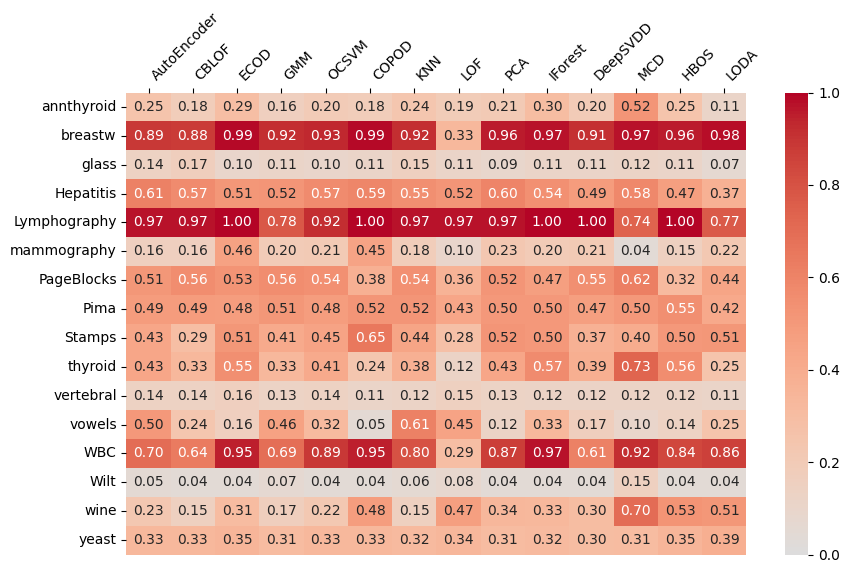

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sympy import rotations

fig, ax = plt.subplots(figsize=(10, 6))

# sns.set_theme(style="whitegrid", font_scale=1)
sns.heatmap(
    df_numeric,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    ax=ax,
    vmin=0,
    vmax=1,
)


ax.xaxis.tick_top()

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
plt.xticks(rotation=45, ha="left")

# plt.tight_layout()
# plt.show()

fig.savefig("img/perf.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

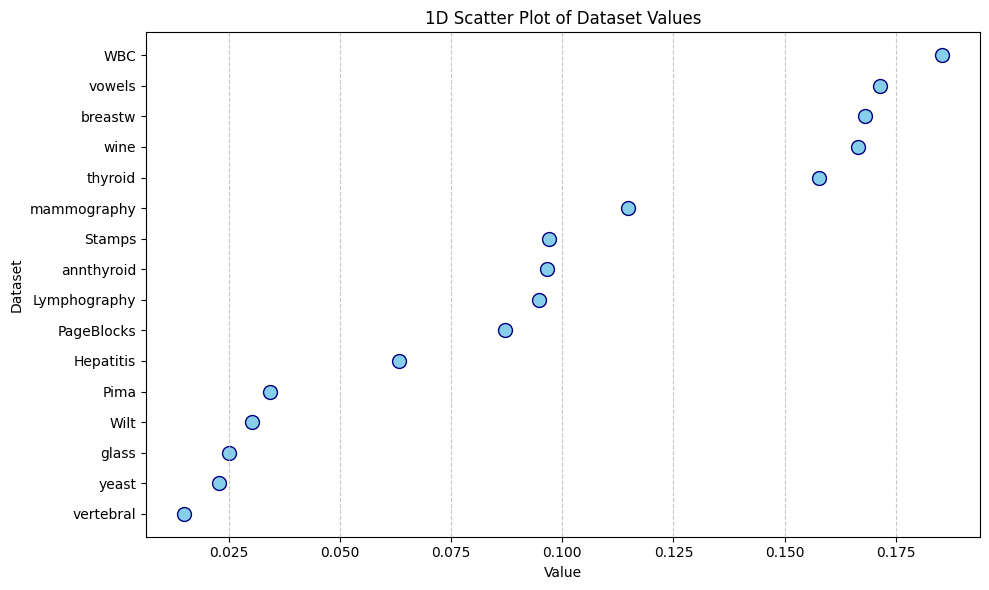

In [27]:
df = pd.Series(df_numeric.std(axis=1)).sort_values()

# Create 1D scatter plot (Dot Plot)
plt.figure(figsize=(10, 6))
plt.scatter(df.values, df.index, color="skyblue", edgecolor="navy", s=100)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Dataset")
plt.title("1D Scatter Plot of Dataset Values")
plt.tight_layout()

# Save the plot
plt.savefig("scatter_plot.png")

# Output the data to a CSV as per instructions
df.to_csv("dataset_values.csv", header=["Value"])

In [30]:
df_numeric.median(axis=1)

annthyroid      0.205
breastw         0.945
glass           0.110
Hepatitis       0.545
Lymphography    0.970
mammography     0.200
PageBlocks      0.525
Pima            0.495
Stamps          0.445
thyroid         0.400
vertebral       0.125
vowels          0.245
WBC             0.850
Wilt            0.040
wine            0.320
yeast           0.330
dtype: float64